In [1]:
import polars as pl
import os
import tqdm
import logging

In [6]:
gtf_file = '/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/downstream_tasks/TSSprediction/data/annotations/GCA_014281875.1_ASM1428187v1_genomic.gtf'

In [42]:
os.path.relpath(gtf_file)

'data/annotations/GCA_014281875.1_ASM1428187v1_genomic.gtf'

In [7]:
def locate_TSS_sites(GTFfile):

    TSSbed=[]

    f = open(GTFfile)
    for line in f:
        table = line.split('\t')
        if len(table) < 3:
            continue
        if table[2] == 'transcript':
            chrom  = table[0]
            strand = table[6] 
            tcx = line.split('transcript_id')[1].split('"')[1]
            geneid = line.split('gene_id')[1].split('"')[1]
            if "gene_name" in line:
                genesymbol = line.split('gene_name')[1].split('"')[1]
            else:
                genesymbol = geneid
            if  strand == "+":
                iregion = {'chrom':chrom, 'TSS':int(table[3])-1, 'strand':strand, 'geneid':geneid, 'gene_symbol':genesymbol, 'annotation': os.path.relpath(GTFfile)}
            elif strand == '-':
                iregion = {'chrom':chrom, 'TSS':int(table[4]), 'strand':strand, 'geneid':geneid, 'gene_symbol':genesymbol, 'annotation': os.path.relpath(GTFfile)}
            TSSbed.append(iregion)
    
    f.close()
    return pl.DataFrame(TSSbed)

In [ ]:
tss = locate_TSS_sites(gtf_file)

In [ ]:
from pysam import FastaFile
import random
import copy
import polars as pl
import os

In [13]:
int(1.1)

1

In [ ]:
class DatasetList():
    
    def __init__(self, 
                    metadata:str|pl.DataFrame='metadata/condensed_metadata.csv', 
                    seed:int = 42,
                    valid_fraction:float = 0.2,
                    chrom_files_dir:str='/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/downstream_tasks/TSSprediction/data/chrom_files'):
        if isinstance(metadata, str):
            self.metadata = pl.read_csv(metadata)
        else:
            self.metadata = metadata
        self.chrom_files_dir = chrom_files_dir
        self.seed = seed
        self.valid_fraction = valid_fraction
        
        
        
    def write_chrom_files(self, genomePath:str):
        
        def add_separators(chroms, sep='\n'):
            return [f'{chrom}\n' for chrom in chroms]
        
        random.seed(self.seed)
        with FastaFile(genomePath) as genome:
            
            chrom_list = genome.references
            chrom_total_count = len(chrom_list)
            chroms_valid_count = int(chrom_total_count * self.valid_fraction) + 1
            chroms_valid = random.sample(chrom_list, k=chroms_valid_count)
            
            chroms_train = list(set(chrom_list) - set(chroms_valid))
            
            chrom_valid_file = os.path.join(self.chrom_files_dir, f"{os.path.basename(genomePath).split('.')[0]}_valid.csv")
            with open(chrom_valid_file, 'w') as valid_handle:
                valid_handle.writelines(add_separators(chroms_valid))
            
            chrom_train_file = os.path.join(self.chrom_files_dir, f"{os.path.basename(genomePath).split('.')[0]}_train.csv")
            with open(chrom_train_file, 'w') as train_handle:
                train_handle.writelines(add_separators(chroms_train))
                
        return chrom_valid_file, chrom_train_file

    def update_metadata_with_chrom_files(self):
        updated_data = []
        for row in self.metadata.iter_rows(named=True):
            
            genomePath = row['genomePath']
            
            chrom_valid_file, chrom_train_file = self.write_chrom_files(genomePath=genomePath)
            
            train_dataset_entry = copy.deepcopy(row)
            valid_dataset_entry = row.copy()
            
            train_dataset_entry['chrom_file'] = os.path.relpath(chrom_train_file)
            valid_dataset_entry['chrom_file'] = os.path.relpath(chrom_valid_file)
            
            updated_data.append(train_dataset_entry)
            updated_data.append(valid_dataset_entry)
            
        return DatasetList(metadata = pl.DataFrame(updated_data), seed=self.seed, chrom_files_dir=self.chrom_files_dir, valid_fraction=self.valid_fraction)
    
    def write_metadata(self, output_file:str):
        
        self.metadata.write_csv(output_file, include_header=True)
        
        

In [43]:
DatasetList().update_metadata_with_chrom_files().write_metadata('/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/downstream_tasks/TSSprediction/metadata/config_entries.csv')

In [ ]:

metadata = pl.read_csv('metadata/condensed_metadata.csv').with_columns(annotation = pl.col('annotation').str.strip_suffix('.gz'))

In [45]:
with open('/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/downstream_tasks/TSSprediction/data/chrom_files/Pongo_pygmaeus_train.csv') as handle:
    out = [chrom.removesuffix('\n') for chrom in handle.readlines()]

In [47]:
tokens = [5]

In [5]:
from pysam import FastaFile
import random
import copy
import polars as pl
import os

def write_chrom_files(genomePath:str, dataset_name:str, chrom_files_dir:str, seed=42, valid_fraction:float=0.2):
    
    def add_separators(chroms, sep='\n'):
        return [f'{chrom}{sep}' for chrom in chroms]
    
    random.seed(seed)
    
    
    with FastaFile(genomePath) as genome:
        
        chrom_list = genome.references
        chrom_total_count = len(chrom_list)
        chroms_valid_count = int(chrom_total_count * valid_fraction) + 1
        chroms_valid = random.sample(chrom_list, k=chroms_valid_count)
        
        chroms_train = list(set(chrom_list) - set(chroms_valid))
        
        chrom_valid_file = os.path.join(chrom_files_dir, f"{dataset_name}_valid.csv")
        with open(chrom_valid_file, 'w') as valid_handle:
            valid_handle.writelines(add_separators(chroms_valid))
        
        chrom_train_file = os.path.join(chrom_files_dir, f"{dataset_name}_train.csv")
        with open(chrom_train_file, 'w') as train_handle:
            train_handle.writelines(add_separators(chroms_train))
            
    return chrom_valid_file, chrom_train_file

In [7]:
write_chrom_files(genomePath='data/cre/genomes_cre/hg38.fa', 
                    dataset_name='Homo_sapiens_CRE', 
                    chrom_files_dir='data/chrom_files')

('data/chrom_files/Homo_sapiens_CRE_valid.csv',
 'data/chrom_files/Homo_sapiens_CRE_train.csv')

In [8]:
write_chrom_files(genomePath='data/cre/genomes_cre/mm10.fa', 
                    dataset_name='Mus_musculus_CRE', 
                    chrom_files_dir='data/chrom_files')

('data/chrom_files/Mus_musculus_CRE_valid.csv',
 'data/chrom_files/Mus_musculus_CRE_train.csv')

In [ ]:
#genome_acc,annotation,genomePath,taxon,chrom_file,split,dataset_name



In [2]:
chrom2TSSlist = {}
for chrom, tss_list in tss.group_by('chrom').agg('TSS').with_columns(TSS = pl.col('TSS').list.sort()).iter_rows():
    chrom2TSSlist[chrom] = tss_list

NameError: name 'tss' is not defined

In [24]:
chrom2TSSlist

{'JABGLX010000146.1': [9833, 12352, 36916, 38065, 64794, 74584],
 'JABGLX010000313.1': [15874, 26588, 30869, 37528, 48578],
 'JABGLX010000507.1': [26296],
 'JABGLX010000212.1': [6906,
  13324,
  14578,
  19364,
  22390,
  57079,
  62922,
  68190,
  102362,
  103099,
  118783,
  122634,
  129826],
 'JABGLX010000184.1': [5752, 11222, 12155, 27136, 27512],
 'JABGLX010000325.1': [6270, 27686],
 'JABGLX010000471.1': [257, 14923, 22807, 25643],
 'JABGLX010000459.1': [27325],
 'JABGLX010000083.1': [97583, 106496],
 'JABGLX010000155.1': [2851],
 'CM024794.1': [29312,
  141982,
  170814,
  171240,
  320215,
  370370,
  378002,
  388176,
  480360,
  489231,
  526405,
  541651,
  560956,
  590781,
  595991,
  688258,
  706040,
  809978,
  909580,
  918899,
  977366,
  1012714,
  1016756,
  1036641,
  1055031,
  1071038,
  1077581,
  1124026,
  1132289,
  1158351,
  1230557,
  1275774,
  1301711,
  1311978,
  1314396,
  1395696,
  1501981,
  1550203,
  1784152,
  1815015,
  1857819,
  1987954,
  1

In [92]:
a = tss.join(metadata, on='annotation', how='left')

In [94]:
a

chrom,TSS,strand,geneid,gene_symbol,annotation,genome_acc,genomePath,taxon
str,i64,str,str,str,str,str,str,str
"""CM024789.1""",7885,"""+""","""GBF38_003607""","""GBF38_003607""","""data/annotations/GCA_014281875…","""GCA_014281875.1""","""data/genomes/Nibea_albiflora.f…","""Actinopteri"""
"""CM024789.1""",14296,"""-""","""GBF38_003608""","""GBF38_003608""","""data/annotations/GCA_014281875…","""GCA_014281875.1""","""data/genomes/Nibea_albiflora.f…","""Actinopteri"""
"""CM024789.1""",15664,"""-""","""GBF38_003609""","""GBF38_003609""","""data/annotations/GCA_014281875…","""GCA_014281875.1""","""data/genomes/Nibea_albiflora.f…","""Actinopteri"""
"""CM024789.1""",23489,"""-""","""GBF38_003610""","""GBF38_003610""","""data/annotations/GCA_014281875…","""GCA_014281875.1""","""data/genomes/Nibea_albiflora.f…","""Actinopteri"""
"""CM024789.1""",30621,"""-""","""GBF38_003611""","""GBF38_003611""","""data/annotations/GCA_014281875…","""GCA_014281875.1""","""data/genomes/Nibea_albiflora.f…","""Actinopteri"""
…,…,…,…,…,…,…,…,…
"""JABGLX010000371.1""",9189,"""-""","""GBF38_000009""","""GBF38_000009""","""data/annotations/GCA_014281875…","""GCA_014281875.1""","""data/genomes/Nibea_albiflora.f…","""Actinopteri"""
"""JABGLX010000371.1""",11291,"""-""","""GBF38_000010""","""GBF38_000010""","""data/annotations/GCA_014281875…","""GCA_014281875.1""","""data/genomes/Nibea_albiflora.f…","""Actinopteri"""
"""JABGLX010000371.1""",22124,"""-""","""GBF38_000008""","""GBF38_000008""","""data/annotations/GCA_014281875…","""GCA_014281875.1""","""data/genomes/Nibea_albiflora.f…","""Actinopteri"""


In [93]:
a.schema

Schema([('chrom', String),
        ('TSS', Int64),
        ('strand', String),
        ('geneid', String),
        ('gene_symbol', String),
        ('annotation', String),
        ('genome_acc', String),
        ('genomePath', String),
        ('taxon', String)])

In [85]:
pl.Schema([('chrom', pl.String),
        ('TSS', pl.Int64),
        ('strand', pl.String),
        ('geneid', pl.String),
        ('gene_symbol', pl.String),
        ('annotation', pl.String),
        ('genome_acc', pl.String),
        ('genomePath', pl.String),
        ('taxon', pl.String)])

Schema([('chrom', String),
        ('TSS', Int64),
        ('strand', String),
        ('geneid', String),
        ('gene_symbol', String),
        ('annotation', String),
        ('genome_acc', String),
        ('genomePath', String),
        ('taxon', String)])

In [48]:
annotationsDir = 'data/annotations'

In [86]:
final_mapping = pl.DataFrame(schema=pl.Schema([('chrom', pl.String),
        ('TSS', pl.Int64),
        ('strand', pl.String),
        ('geneid', pl.String),
        ('gene_symbol', pl.String),
        ('annotation', pl.String),
        ('genome_acc', pl.String),
        ('genomePath', pl.String),
        ('taxon', pl.String)]))

In [101]:
metadata = pl.read_csv('metadata/condensed_metadata.csv').with_columns(annotation = pl.col('annotation').str.strip_suffix('.gz'))
annotations = os.listdir(annotationsDir)
for annotation in tqdm.tqdm(annotations, total = len(annotations)):
    if 'gtf' not in annotation:
        continue
    annotation_full_path = os.path.join(annotationsDir, annotation)
    tss_df = locate_TSS_sites(annotation_full_path)
    assert len(tss_df) > 0
    tss_df = tss_df.join(metadata, on='annotation', how='left')
    final_mapping = pl.concat([final_mapping, tss_df])
    

100%|██████████| 70/70 [02:33<00:00,  2.20s/it]


In [103]:
final_mapping.write_csv('dataset.csv')

In [117]:
import os
import hashlib
import logging
import numpy as np
import pandas as pd
import h5py
import tqdm
import torch
from torch.utils.data import Dataset
from pysam import FastaFile
from pathlib import Path
import threading
from transformers import AutoTokenizer

import sys
from typing import List, Dict


from concurrent.futures import ThreadPoolExecutor
from concurrent.futures import as_completed
import polars as pl

import random

Plan


In [4]:
with FastaFile('/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/downstream_tasks/TSSprediction/data/genomes/Danio_rerio.fasta') as genome:
    print(genome.references)

['NC_133176.1', 'NC_133177.1', 'NC_133178.1', 'NC_133179.1', 'NC_133180.1', 'NC_133181.1', 'NC_133182.1', 'NC_133183.1', 'NC_133184.1', 'NC_133185.1', 'NC_133186.1', 'NC_133187.1', 'NC_133188.1', 'NC_133189.1', 'NC_133190.1', 'NC_133191.1', 'NC_133192.1', 'NC_133193.1', 'NC_133194.1', 'NC_133195.1', 'NC_133196.1', 'NC_133197.1', 'NC_133198.1', 'NC_133199.1', 'NC_133200.1', 'NC_002333.2']


In [163]:
dataset = CreDataset(tokenizer='/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/data/tokenizers/t2t_1000h_multi_32k',
            cache_dir='/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/downstream_tasks/TSSprediction/cache',
            annotation='data/annotations/GCF_017654675.1_Xenopus_laevis_v10.1_genomic.gtf',
            genome='data/genomes/Xenopus_laevis.fasta',
            cre_bed=None,
            inputType='TSS',
            token_len_for_fetch = 10,
            max_seq_len = 1024,
            loglevel = logging.WARNING,
            taxon='') 

KeyError: ''

In [121]:
dataset[0]

{'input_ids': tensor([  1, 599, 962,  ..., 246, 170,   2]),
 'attention_mask': tensor([1, 1, 1,  ..., 1, 1, 1]),
 'labels': tensor([[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]),
 'labels_mask': tensor([[ True],
         [False],
         [False],
         ...,
         [False],
         [False],
         [False]]),
 'taxon': 3,
 'seq': 'TATTGCTTAAAAGTGAATACTTGCAGCTATTCGGTGGTGCCATCCTTGCTTTCCTACATTCAATCAATTGGTGGGTGCAGTTCTCCGTAGAAGTATTGTGGTTTGACCTAAAATAAAGAAAAGAAAAGTTCCAAAGTTAAATTTCTCCCCAAAATTGCCATGACAAAATAAAAACAACCTGCTAAGAATCATTCCAACTTCTCCTTAACAAATGGTACCCTGCATGTACGGGTGCAACTAAATATGCGGTCTCCAAACAGCCCAAAACAGGGTCAATACACAAGAGCAATTTCAGCTGGAAAGCTTGGGACTTGTGCTCTAGGTGCACACCTTGCAGTTCTTCAGTTTAACACCCCCTACCTGTGAAATACCCACAAACTATATATTGCTTGAAGTGCACACCTGTAGCTATTCAGTGCACCATCTTTGCTTACCTACAAGCAGCTCTGTGGGCACAGTTCTCCGTAGAACTGCATGTATGGGTGCACCTAAAGACGCGGCCTCTAAACACCCCAAAACAGGGTCAATACTCAAGAGCAATTTAAGCTGGAAAGCTTGGGACTGCGCTCAAAGTGCACACCTTGCAGTTCTTCAGTCTAAACACCACCTT

In [164]:
dataset = CreDataset(tokenizer='/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/data/tokenizers/t2t_1000h_multi_32k',
            cache_dir='/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/downstream_tasks/TSSprediction/cache',
            genome='/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/downstream_tasks/TSSprediction/data/cre/genomes_cre/hg38.fa',
            cre_bed='/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/downstream_tasks/TSSprediction/data/cre/GRCh38-cCREs.bed',
            inputType='CRE',
            token_len_for_fetch = 10,
            max_seq_len = 1024,
            loglevel = logging.WARNING,
            min_cre_number=10,
            min_cre_coverage=0.3,
            taxon='Mammalia') 

In [165]:
len(dataset)

10001

In [156]:
labels = []
for i in range(10000): 
    sample = dataset[i]
    label = (sample['labels'] * sample['labels_mask']).sum()
    labels.append(label)

In [157]:
sum(labels)

tensor(4564.)

In [114]:
dataset = pl.read_csv('/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/downstream_tasks/TSSprediction/dataset.csv')

In [116]:
dataset['taxon'].unique()

taxon
str
"""Lepidosauria"""
"""Chondrichthyes"""
"""Mammalia"""
"""Amphibia"""
"""Actinopteri"""
"""Myxini"""
"""Aves"""


In [ ]:
import polars as pl



In [11]:
dataset.unique().columns

['chromosome',
 'TSS',
 'strand',
 'geneid',
 'gene_symbol',
 'annotation',
 'genome_acc',
 'genome_path',
 'taxon',
 'is_TSS']

In [ ]:
tss_locations = {}


In [8]:
dataset.with_columns(genome_path = pl.col('genome_path').str.strip_suffix('.gz')).write_csv('/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/downstream_tasks/TSSprediction/dataset.csv')

In [8]:
dataset.with_columns(is_TSS=1).write_csv('/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/downstream_tasks/TSSprediction/dataset.csv')

In [ ]:
from TSSprediction.GENA_LM.downstream_tasks.TSSprediction.TSS_dataset_old import TSSDataset

/home/jovyan/miniconda3/envs/exprflash/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
TSSDataset(mapping_file='/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/downstream_tasks/TSSprediction/dataset.csv',
            tokenizer='/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/data/tokenizers/t2t_1000h_multi_32k',
            cache_dir='/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/downstream_tasks/TSSprediction/cache',
            num_before = 512,
            token_len_for_fetch = 10,
            max_seq_len = 1024,
            loglevel = logging.WARNING,
            data_workers = 10) 

Tokenizing:   5%|▍         | 264817/5499911 [27:43<9:29:05, 153.32it/s] 

KeyboardInterrupt: 

In [21]:
cre_bed_human = pl.read_csv('/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/downstream_tasks/TSSprediction/data/cre/GRCh38-cCREs.bed', has_header=False, separator='\t', new_columns=('chrom', 'start', 'end', 'smth', 'smth2', 'type'))

In [24]:
data = cre_bed_human['type'].value_counts().sort(by='count', descending=True)

In [25]:
data

type,count
str,u32
"""dELS""",1469205
"""pELS""",249464
"""CA""",245985
"""CA-CTCF""",126034
"""TF""",105286
"""CA-H3K4me3""",79246
"""PLS""",47532
"""CA-TF""",26102


Text(0, 0.5, 'count')

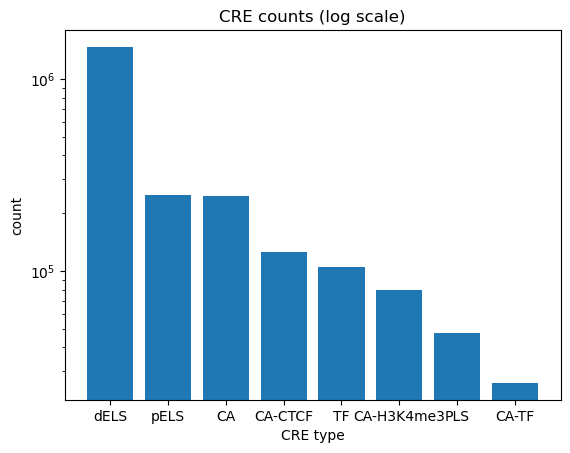

In [31]:
import matplotlib.pyplot as plt
plt.bar(x=np.arange(1, len(data)+1), height = data['count'])
plt.xticks(ticks=np.arange(1, len(data)+1), labels=data['type'])
plt.yscale('log')
plt.title('CRE counts (log scale)')
plt.xlabel('CRE type')
plt.ylabel('count')

In [5]:
import logging
import os
from pathlib import Path
import shutil
from hydra.utils import instantiate
import torch
from argparse import ArgumentParser
from hydra import initialize_config_dir, compose
import math
from accelerate import Accelerator

from torch.utils.data import DataLoader, DistributedSampler, ConcatDataset, Dataset
from typing import List, Tuple, Any

# Fix for PyTorch 2.6+ weights_only default change
import numpy
torch.serialization.add_safe_globals([
    numpy.core.multiarray._reconstruct,
    numpy.ndarray, numpy.dtype, numpy.dtypes.UInt32DType
])

from omegaconf import OmegaConf

In [22]:
config = 'configs/small_config.yaml'
log_level='INFO'
os.environ['GENALM_HOME'] = '/workspace-SR003.nfs2/estsoi/TSSprediction'

def _collect_dataset_configs(experiment_config, prefix: str) -> List[Any]:
    """Берёт все ключи вида train_dataset*, valid_dataset*."""
    return [v for k, v in experiment_config.items() if str(k).startswith(prefix)]

def build_dataset_from_cfgs(dataset_cfgs: List[Any]) -> Dataset:
    """Instantiate -> Dataset or ConcatDataset."""
    datasets = [instantiate(cfg) for cfg in dataset_cfgs]
    if len(datasets) == 0:
        raise ValueError("No datasets after instantiate()")
    if len(datasets) == 1:
        return datasets[0]
    return ConcatDataset(datasets)

def gradient_accumulation_steps(batch_size: int, total_batch_size: int) -> int:
	return min(1, math.ceil(total_batch_size / batch_size))


accelerator = Accelerator()

logging.basicConfig(format='%(asctime)s - %(name)s - %(levelname)s - %(message)s', level=log_level)
logger = logging.getLogger()
experiment_config_path = Path(config).expanduser().absolute()
if os.environ.get('CUDA_VISIBLE_DEVICES', None) is None:
	os.environ['CUDA_VISIBLE_DEVICES'] = ','.join([str(i) for i in range(torch.cuda.device_count())])
logger.info(f"CUDA_VISIBLE_DEVICES: {os.environ['CUDA_VISIBLE_DEVICES']}")
logger.info(f"CUDA DEVICE COUNT: {torch.cuda.device_count()}")
with initialize_config_dir(str(experiment_config_path.parents[0])):
	experiment_config = compose(config_name=experiment_config_path.name)
output_dir = experiment_config.output_dir
logger.info(f"Output directory: {output_dir}")
# copy experiment config to output_dir
if not os.path.exists(output_dir):
	os.makedirs(output_dir)
shutil.copy(config, os.path.join(output_dir, "config.yaml"))


# Datasets
logger.info('Collecting dataset configs...')
train_dataset_configs = _collect_dataset_configs(experiment_config=experiment_config, prefix='train_dataset')
eval_dataset_configs = _collect_dataset_configs(experiment_config=experiment_config, prefix='valid_dataset')

logger.info('Building concat datasets from configs...')
train_concat_dataset = build_dataset_from_cfgs(train_dataset_configs)
eval_concat_dataset = build_dataset_from_cfgs(eval_dataset_configs)

2026-04-01 16:48:12,363 - root - INFO - CUDA_VISIBLE_DEVICES: 0,1,2,3,4,5,6
2026-04-01 16:48:12,364 - root - INFO - CUDA DEVICE COUNT: 7
/tmp/ipykernel_3691419/3672297242.py:31: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(experiment_config_path.parents[0])):
2026-04-01 16:48:12,432 - root - INFO - Output directory: /workspace-SR003.nfs2/estsoi/TSSprediction/runs/CRE_prediction
2026-04-01 16:48:12,438 - root - INFO - Collecting dataset configs...
2026-04-01 16:48:12,440 - root - INFO - Building concat datasets from configs...


In [7]:
os.environ['PYTHONPATH'] = '/home/jovyan/shares/SR003.nfs2/aspeedok/ModernBERT/src:/home/jovyan/shares/SR003.nfs2/aspeedok/ModernBERT/src::/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/downstream_tasks/TSSprediction:/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM'

In [30]:
trainer_config = experiment_config.trainer.copy()

In [31]:
trainer = instantiate(trainer_config)

InstantiationException: Error locating target 'CRE_model.CreModel', set env var HYDRA_FULL_ERROR=1 to see chained exception.
full_key: trainer.model

In [29]:
trainer_config.update({'__target__': build_dataset_from_cfgs, 'dataset_cfgs': train_dataset_configs})

ConfigKeyError: Key '__target__' is not in struct
    full_key: trainer.__target__
    object_type=dict

In [ ]:
 

# Initialize Trainer with custom trainer class
trainer_config = experiment_config.trainer.copy()

trainer_config['train_dataset'] = train_concat_dataset
trainer_config['eval_dataset'] = eval_concat_dataset
trainer = instantiate(trainer_config)


# Prepare trainer with accelerator
trainer = accelerator.prepare(trainer)
# Train and evaluate
resume_from_checkpoint = experiment_config.get('resume_from_checkpoint', None)
trainer.train(resume_from_checkpoint=resume_from_checkpoint)
trainer.evaluate()

In [15]:
import logging
import os
from pathlib import Path
import shutil
from hydra.utils import instantiate
import torch
from argparse import ArgumentParser
from hydra import initialize_config_dir, compose
import math
from accelerate import Accelerator

from torch.utils.data import DataLoader, DistributedSampler, ConcatDataset, Dataset
from typing import List, Tuple, Any
from safetensors.torch import load_file
import os

In [ ]:
import logging
import os
from pathlib import Path
import shutil
from hydra.utils import instantiate
import torch
from argparse import ArgumentParser
from hydra import initialize_config_dir, compose
import math
from accelerate import Accelerator

from torch.utils.data import DataLoader, DistributedSampler, ConcatDataset, Dataset
from typing import List, Tuple, Any
from safetensors.torch import load_file
import os
import numpy as np

checkpoint = '/workspace-SR003.nfs2/estsoi/TSSprediction/runs/CRE_prediction/checkpoint-31750/model.safetensors'


def _collect_dataset_configs(experiment_config, prefix: str) -> List[Any]:
    """Берёт все ключи вида train_dataset*, valid_dataset*."""
    return [v for k, v in experiment_config.items() if str(k).startswith(prefix)]

def build_dataset_from_cfgs(dataset_cfgs: List[Any]) -> Dataset:
    """Instantiate -> Dataset or ConcatDataset."""
    datasets = [instantiate(cfg) for cfg in dataset_cfgs]
    if len(datasets) == 0:
        raise ValueError("No datasets after instantiate()")
    if len(datasets) == 1:
        return datasets[0]
    return ConcatDataset(datasets)


def instantiate_model(experiment_config: str|Path):
    if not isinstance(experiment_config, Path):
        experiment_config = Path(experiment_config).absolute()
    with initialize_config_dir(str(experiment_config.parents[0])):
        experiment_config = compose(config_name=experiment_config.name)
    model = instantiate(experiment_config['model'])
    
    state_dict = load_file(checkpoint, device="cpu")
    # 3. Load the weights into your model
    model.load_state_dict(state_dict)
    
    return model


def instantiate_dataset(experiment_config: str|Path, prefix: str):
    if not isinstance(experiment_config, Path):
        experiment_config = Path(experiment_config).absolute()
    with initialize_config_dir(config_dir=str(experiment_config.parents[0])):
        experiment_config = compose(config_name=experiment_config.name)
    dataset_configs = _collect_dataset_configs(experiment_config=experiment_config, prefix=prefix)
    dataset = build_dataset_from_cfgs(dataset_cfgs=dataset_configs)
    
    return dataset


def select_indices(dataset):
    dataset_len = len(dataset)
    positive_class = []
    negative_class = []
    for idx in range(dataset_len):
        dataset_entry = dataset[idx]
        label = dataset_entry['labels'].sum()
        if label == 1:
            positive_class.append(idx)
        else:
            negative_class.append(idx)
            
    positive_count = len(positive_class)
    negative_count = len(negative_class)
    
    if len(positive_class) < len(negative_class):
        negative_class = 
        
    return positive_class, negative_class


def balance_classes(dataset):
    
    
    pass

def calculate_metrics(inputs, outputs):
    pass



In [1]:
# load model (class and statedict)
# write code for model assessment (perfomance on valid cre and tss)
# write function, that takes genome file as input and outputs intervals for model training
# 

In [1]:
def instantiate_model(experiment_config: str|Path):
    if not isinstance(experiment_config, Path):
        experiment_config = Path(experiment_config).absolute()
    with initialize_config_dir(str(experiment_config.parents[0])):
        experiment_config = compose(config_name=experiment_config.name)
    model =  instantiate(experiment_config['model'])
    
    return model

NameError: name 'Path' is not defined

In [13]:
instantiate_model('configs/run_config.yaml')

/tmp/ipykernel_3692683/1086933749.py:4: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(experiment_config.parents[0])):


InstantiationException: Error locating target 'CRE_model.CreModel', set env var HYDRA_FULL_ERROR=1 to see chained exception.
full_key: model

In [ ]:
import polars as pl

In [5]:
import h5py
file = h5py.File('/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/downstream_tasks/TSSprediction/cache/TSS_Ambystoma_mexicanum_train.642f636d7e1fe430.h5',rdcc_nbytes=1000*1024**2, libver='latest', driver='sec2')

In [ ]:
len(file)

: 

In [ ]:
data_dict = {}
with file as f:
    for key in f.keys():
        # [()] converts the HDF5 dataset into a NumPy array
        data_dict[key] = f[key][()] 

: 